# **Physical Informed Neural Networks**

---

## **Differential equations and integrators**

In computational physics, there exist many approaches to numerical analysis for studying differential equations. However, in order to integrate them, usually some boundary conditions are needed, as for instance the starting position  and velocity $(x_0,v_0)$ in classical dynamics.

Usually, a differential equation of $k$ order can be described by an implicit function $F$:

\begin{equation}
  F(x, f, f', f'', ..., f^{(k)}) = 0
\end{equation}

with $x$ being an independent variable defined in the $\Omega$ domain. Usually, in classical dynamics the independent variable is the time $t$, while $x$ stands for the position of the point particle.

One of the most notorious differential equation in mechanics is provided by the harmonic oscillator:

\begin{equation}
  \ddot f + \omega^2 f = 0
\end{equation}

### The Cauchy problem

In order to solve a $k$-order differential equation, $k-1$ boundary conditions are needed on each derivative order of $f$. For second-order differential equations, which are the most notorious in physics, constraints are required on $f(t_0)$ and $\dot f(t_0)$, which match the $(x_0, v_0)$ tuple previously recalled.

Every standard integration method, such as Euler, leapfrog or Runge-Kutta, needs to make evolve any $k$-th derivative in order to achieve the numerical solution $f$ for the problem. In the picture, the evolution of $x$ and $v$ when integrating the laws of motion through the **leapfrog method**:

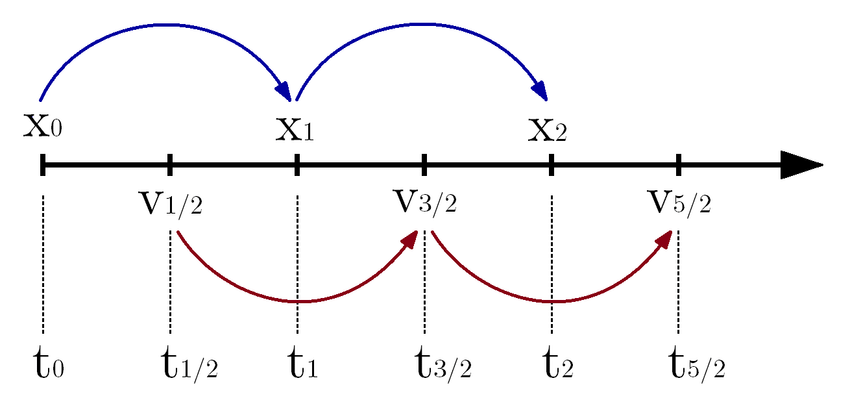

### Solving the harmonic oscillator differential equation via the leapfrog method

Here we want to evaluate how the systems evolves in time, if it is determined by the differential equation

$$
x''(t) + x(t) = 0
$$

We introduce the velocity $v=\frac{dx}{dt}$, so the differential equation can be written as $x''(t)=-v$, and then we define the boundary conditions $(x_0,v_0)$.

The **leapfrog method** evaluates the position after each step using the velocity after a semi-step:

$$
x_{n+1} = x_n + dt\,v_{n+\frac{1}{2}}
$$

while this new position is exploited to evaluate the new velocity after a semi-step:

$$
v_{n+\frac{3}{2}} = v_{n+\frac{1}{2}} + dt\,x_{n+1}
$$

Finally, the velocities after each step are determined by

$$
v_{n} = \frac{v_{n+\frac{1}{2}}+v_{n+\frac{3}{2}}}{2}
$$

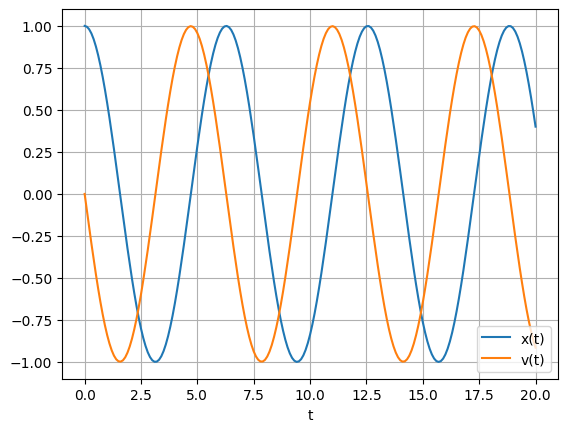

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1          # time-step
T = 20            # total time interval
N = int(T / dt)   # number of steps

t = np.zeros(N + 1)
x = np.zeros(N + 1)
v_half = np.zeros(N + 1)

# Boundary conditions (x_0, v_0)
x[0] = 1.0   # initial position
v0 = 0.0     # initial velocity

# Initial velocity in dt/2
# v(dt/2) = v(0) + (dt/2)*a(x(0))
v_half[0] = v0 + 0.5 * dt * (-x[0])

# Leapfrog
for n in range(N):
    # Updating the position after one step
    x[n+1] = x[n] + dt * v_half[n]

    # Updating the velocity after one half a step
    v_half[n+1] = v_half[n] + dt * (-x[n+1])

    # Updating the time
    t[n+1] = t[n] + dt

# Building the velocity array step by step
v = np.zeros(N + 1)
v[0] = v0
for n in range(1, N + 1):
    v[n] = 0.5 * (v_half[n-1] + v_half[n])

plt.plot(t, x, label='x(t)')
plt.plot(t, v, label='v(t)')
plt.xlabel('t')
plt.legend()
plt.grid()
plt.show()

## **Machine Learning approach**

The motivation in using Machine Learning methods in solving differential equation is mainly the fact that not every significative differential equation is a second order differential equation. The more the order increases, the harder the numerical problem gets.

We know that the goal of many Machine Learning techniques consists of fitting experimental data $\{(x_j, y_j)\}_{j=1}^N$ with a suitable function $f(x_j) = y_j$, or better, changing the labels to

$$
(x_j, y_j)\longrightarrow (t_j, x_j)
$$

we want to fit the function

$$
f(t_j) = x_j
$$

with $t$ being the independent variable and $x$ the corresponding position.

Usually, such a fit requires a huge number of data points, in order to leverage the correctness on the prediction by the model. So, the key feature is to introduce the differential equation (or better, the implicit function it describes it) as a constraint during the training.

Such constraints are translated into two loss function: the loss $L_2$ for fitting the data, the loss $L_1$ one to solve the differential equation $F(t, f, f', ..., f^{(n)})=0$. The overall loss $L_{tot}$ can be thus computed summing these two: employing the MSE loss for regression, the overall loss $L$ reads as

$$
  L_{tot} = \lambda_1 L_1\Big(F\big(t_j,\dots,f^{(n)}(t_j)\big), 0\Big) + \lambda_2 L_2\big(f(t_j), x_j\big)
$$

Usually the two losses are determined by the **Mean Squared Error functions**, and the data given to the two losses can be organized in different batches.

Given such a loss function, it is possible to train the model as it follows:



```
def diff_eq(t_eq):
    ## Return the implicit function ##
    return F(t_eq, f, f_1, ...)
```



In order to derive a batch of variable $x$ with respect to $t$, pytorch allows to invoke the following command:



```
x_t = torch.autograd.grad(x.sum(), t, create_graph=True)[0]
```



A sketch on how to implement the training method in your PINN class:



```
def train_step(t_eq, t_data, x_data):
    ## Get the loss from differential equation ##
    ## zeros is a tensor of 0 elements with the
    ## same size of diff_eq
    loss_eq = MSE(diff_eq(t_eq), zeros)

    ## Data loss ##
    loss_data = MSE(x_data, model(t_data))

    ## Overall loss ##
    loss_total = loss_data + loss_eq

    ## Backpropagation ##
    loss_total.backward()
    optimizer.step()

    ## Return overall loss ##
    return loss_total.item()
```



From the previous snippet of code, remember to recall all the methods from the universal template class, thus mainly to add self. instance where opportune.

## **Pros and cons of PINN**

At the end of this introduction, it is possible to draw some conclusions about PINN:

*   with respect to standard integration methods, to predict the $f$ model no informations are needed over the higher-order derivatives, but instead only from $f$ itself;
*   additional constraints from the differential equation boost by far the precision on predictions from Neural Networks. Fewer data are needed to fit the model $f$;
*   on the other side, by such vanilla approach, informations are required on the physical parameters inside the differential equation. Recalling the usual example from the harmonic oscillator, in order to implement PINN, $\omega$ has to be known.
*   in the real world, data are noisy: in order to counterbalance such effect, it is opportune to weight properly the $\lambda_i$ coefficients when writing down the total loss.



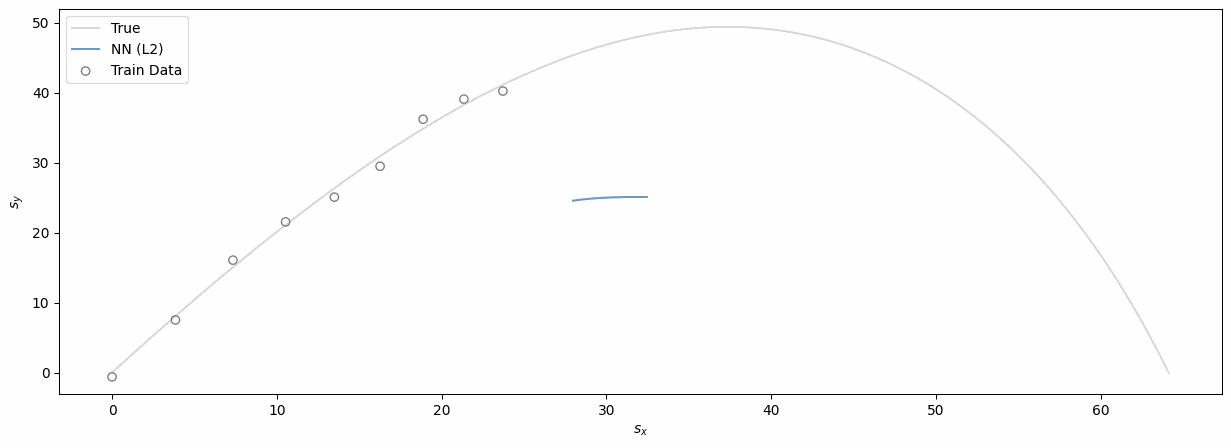

## **First order differential equations: Stokes' law**

### **Theoretical perspective**

Due to the second law of classical dynamics, first order differential equations in physics are rare. An example is featured when studying the motion of a body in a fluid with viscosity $\eta$. Specifically, in literature it is common to deal with a sphere of radius $R$ floating in a liquid. Thinking velocity instead of position as the dynamical variable of the equation, the overall force $\textbf{F}=m \dot{\textbf{v}}$ is given by

\begin{equation}
  m \dot{\textbf{v}} = 6 \pi \eta R \textbf{v} + (\rho_s - \rho_f) \frac{4\pi}{3} R^3 \textbf{g}
\end{equation}

where $\rho_s$ and $\rho_f$ are the densities, respectively, for the sphere and the fluid, and $g$ is the gravity acceleration. The first force is the viscous drag, while the latter is the linear combination of the sphere weight and the Archimede's principle.
Supposing the motion to be vertical, thus monodimensional, the above equation can be reshaped as

\begin{equation}
  m \dot{v} = -6 \pi \eta R v + (\rho_s - \rho_f) \frac{4\pi}{3} R^3 g
\end{equation}

Stokes_sphere.svg

An anstatz is $v=Ae^{\gamma t} +C$, which inserted in the above equation yields the following result:

\begin{equation}
  A\gamma e^{\gamma t} = - 6 \pi \eta R A e^{t \gamma} - 6 \pi \eta R C + (\rho_s - \rho_f) \frac{4\pi}{3} R^3 g
\end{equation}

With a few calculations, it follows that

\begin{equation}
  \begin{cases}
  \gamma = - \frac{6 \pi \eta R}{m} = - \frac{1}{\tau} \\
  C = (\rho_s - \rho_f) \frac{2}{9 \eta} R^2 g
  \end{cases}
\end{equation}

The $-\gamma$ constant hides a time scale, which is the reason why we recall it $1/\tau$. The overall solution is given by

\begin{equation}
  v(t) = A e^{-\frac{t}{\tau}} + (\rho_s - \rho_f) \frac{2}{9 \eta} R^2 g
\end{equation}

The $A$ constant can be only determined by boundary conditions, mainly by setting the initial velocity $v(0)=v_0$.

### **Hands on: Stokes' law implemented by PINN**

**Goal**: the purpose of the next exercise consists of predicting the velocity trend for a sphere in a viscous fluid, in the $[0, 2\tau]$ domain ($\tau$ being the time length for damping). At the end, plot the predicted model and compare it with the true solution of the equation. The following steps are required:


1.   Train the PINN over the STOKES_dataset.npz dataset
2.   Compare the result with a model trained without any help from the differential equation
3.   Train the PINN over the STOKES_dataset_noisy.npz dataset



**Hints**

1.   The model has to be trained on both the given data and the constraint given by Stokes' law. The differential equation Stokes' law obeys to, in its scalar fashion, is given by $\dot v + v/\tau - V = 0$. For sake of simplicity, we merged all the dynamical parameters, such as $R$, $\rho_f$, $\rho_s$ and so on into $\tau$ and $V$, $\tau$ being the time length of the system and $V$ the average velocity after damping.
2.   In order to train the PINN, we need to fit the data into the differential equation. Remember, the overall loss is provided by the sum of the loss on the differential equation and on the data training. Handling non-noisy data, you may just sum the two losses, while on noisy data different weights may help the training.
3.   As far as we are performing a regression, MSE loss will come in handy for our task, both for the differential equation and the dataset.
4.   The model has to be trained into the $[0;2\tau]$ domain. Nevertheless, the dataset provides times ranged into the $[0;τ]$ interval. A useful suggestion would be to generate a set of times $t_{eq}$ ranged in $[0;2\tau]$ in order to train the loss on the differential equation. In fact, the training on the differential equation does just need a set of $t$ as inputs, regardless of beloning to the dataset or being randomly generated. Therefore, use random generated times for the training on the differential equation and the dataset $\{t_i, v_i\}_{i=1}^{10}$ for the boundary conditions.
5.   As the dataset is very tiny (ten elements), you will see the power of PINN when fitting the curve!
